# Selección de Factores

* Ines Gonzales
* Jose Arenas
* Jhonier Correa

Multicolinealidad = correlaciones altas entre variables predictoras







In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de datos

In [ ]:
#Cargamos los datos
data=pd.read_csv('dataset-tipodemetastasis-limpieza-weka.csv', sep=',')
data.head()

,patient_race,payer_type,patient_age,breast_cancer_diagnosis_code,Region,population,density,age_median,age_under_10,age_10_to_19,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,tipo_metastasis
0,White,COMMERCIAL,62,C50.2_C50.4,West,39121.878790,2295.939394,38.200000,11.878788,13.354545,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,Linfatico
1,White,COMMERCIAL,43,C50.1,South,21996.683330,626.236667,37.906667,13.028333,14.463333,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,Linfatico
2,White,COMMERCIAL,45,C50.2_C50.4,West,32795.325580,1896.220930,42.871429,10.071429,12.135714,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,Linfatico
3,White,'MEDICARE ADVANTAGE',66,C50.9_C79.81,Northeast,5643.771429,219.362857,45.180000,8.511429,14.857143,...,13.717143,8.888235,0.638235,25.000000,4.797143,7.745714,40.107248,6.181812,13.562528,VisceralSistemico
4,White,COMMERCIAL,60,C50.3_C50.5,Midwest,3404.100000,25.733333,42.790000,11.983333,13.256667,...,15.260000,10.890000,0.503333,24.275862,8.753333,7.506667,37.646770,7.295977,12.914805,Linfatico


In [ ]:
# Revisamos filas y columnas
data.shape

(9412, 73)

In [ ]:
# Tipo de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9412 entries, 0 to 9411
Data columns (total 73 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_race                  9412 non-null   object 
 1   payer_type                    9412 non-null   object 
 2   patient_age                   9412 non-null   int64  
 3   breast_cancer_diagnosis_code  9412 non-null   object 
 4   Region                        9412 non-null   object 
 5   population                    9412 non-null   float64
 6   density                       9412 non-null   float64
 7   age_median                    9412 non-null   float64
 8   age_under_10                  9412 non-null   float64
 9   age_10_to_19                  9412 non-null   float64
 10  age_20s                       9412 non-null   float64
 11  age_30s                       9412 non-null   float64
 12  age_40s                       9412 non-null   float64
 13  age

In [ ]:
# Correción de tipo de datos
for i in data.columns:
  if data[i].dtype=='object':
    data[i]=data[i].astype('category')

In [ ]:
# Verificación de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9412 entries, 0 to 9411
Data columns (total 73 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   patient_race                  9412 non-null   category
 1   payer_type                    9412 non-null   category
 2   patient_age                   9412 non-null   int64   
 3   breast_cancer_diagnosis_code  9412 non-null   category
 4   Region                        9412 non-null   category
 5   population                    9412 non-null   float64 
 6   density                       9412 non-null   float64 
 7   age_median                    9412 non-null   float64 
 8   age_under_10                  9412 non-null   float64 
 9   age_10_to_19                  9412 non-null   float64 
 10  age_20s                       9412 non-null   float64 
 11  age_30s                       9412 non-null   float64 
 12  age_40s                       9412 non-null   fl

In [ ]:
# Revisión
data.head()

,patient_race,payer_type,patient_age,breast_cancer_diagnosis_code,Region,population,density,age_median,age_under_10,age_10_to_19,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,tipo_metastasis
0,White,COMMERCIAL,62,C50.2_C50.4,West,39121.878790,2295.939394,38.200000,11.878788,13.354545,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,Linfatico
1,White,COMMERCIAL,43,C50.1,South,21996.683330,626.236667,37.906667,13.028333,14.463333,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,Linfatico
2,White,COMMERCIAL,45,C50.2_C50.4,West,32795.325580,1896.220930,42.871429,10.071429,12.135714,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,Linfatico
3,White,'MEDICARE ADVANTAGE',66,C50.9_C79.81,Northeast,5643.771429,219.362857,45.180000,8.511429,14.857143,...,13.717143,8.888235,0.638235,25.000000,4.797143,7.745714,40.107248,6.181812,13.562528,VisceralSistemico
4,White,COMMERCIAL,60,C50.3_C50.5,Midwest,3404.100000,25.733333,42.790000,11.983333,13.256667,...,15.260000,10.890000,0.503333,24.275862,8.753333,7.506667,37.646770,7.295977,12.914805,Linfatico


# 2. Descripción estadística de los datos


In [ ]:
# Cargar libreria profiling
#!pip install ydata-profiling

# Perfilado de datos
#from ydata_profiling import ProfileReport
#profile_data=ProfileReport(data, minimal=True) # minimal=False
#profile_data
#Guardamos en html el perfilado de datos
#profile_data.to_file(output_file="outputmetastasisselecciondefactores.html")

# 3. Selección de factores
Codificando la variable objetivo

In [ ]:
#Codificación de variable objetivo
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['tipo_metastasis'] = le.fit_transform(data['tipo_metastasis'])
data.head()

,patient_race,payer_type,patient_age,breast_cancer_diagnosis_code,Region,population,density,age_median,age_under_10,age_10_to_19,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,tipo_metastasis
0,White,COMMERCIAL,62,C50.2_C50.4,West,39121.878790,2295.939394,38.200000,11.878788,13.354545,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
1,White,COMMERCIAL,43,C50.1,South,21996.683330,626.236667,37.906667,13.028333,14.463333,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
2,White,COMMERCIAL,45,C50.2_C50.4,West,32795.325580,1896.220930,42.871429,10.071429,12.135714,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,1
3,White,'MEDICARE ADVANTAGE',66,C50.9_C79.81,Northeast,5643.771429,219.362857,45.180000,8.511429,14.857143,...,13.717143,8.888235,0.638235,25.000000,4.797143,7.745714,40.107248,6.181812,13.562528,2
4,White,COMMERCIAL,60,C50.3_C50.5,Midwest,3404.100000,25.733333,42.790000,11.983333,13.256667,...,15.260000,10.890000,0.503333,24.275862,8.753333,7.506667,37.646770,7.295977,12.914805,1


In [ ]:
# Se reliza copia de los datos para realizar el analisis sin modificar el dataset original
#Copia de los datos
df = data.copy()

In [ ]:
# Creacion de dummies
df = pd.get_dummies(df, columns=['patient_race', 'payer_type', 'Region','breast_cancer_diagnosis_code'], drop_first=False, dtype=int)
pd.set_option('display.max_columns', None)
df.head()

,patient_age,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,age_50s,age_60s,age_70s,age_over_80,male,female,married,divorced,never_married,widowed,family_size,family_dual_income,income_household_median,income_household_under_5,income_household_5_to_10,income_household_10_to_15,income_household_15_to_20,income_household_20_to_25,income_household_25_to_35,income_household_35_to_50,income_household_50_to_75,income_household_75_to_100,income_household_100_to_150,income_household_150_over,income_household_six_figure,income_individual_median,home_ownership,housing_units,home_value,rent_median,rent_burden,education_less_highschool,education_highschool,education_some_college,education_bachelors,education_graduate,education_college_or_above,education_stem_degree,labor_force_participation,unemployment_rate,self_employed,farmer,race_white,race_black,race_asian,race_native,race_pacific,race_other,race_multiple,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,tipo_metastasis,patient_race_Asian,patient_race_Black,patient_race_Hispanic,patient_race_Other,patient_race_White,payer_type_'MEDICARE ADVANTAGE',payer_type_COMMERCIAL,payer_type_MEDICAID,Region_Midwest,Region_Northeast,Region_South,Region_West,breast_cancer_diagnosis_code_C50.0,breast_cancer_diagnosis_code_C50.1,breast_cancer_diagnosis_code_C50.2_C50.4,breast_cancer_diagnosis_code_C50.3_C50.5,breast_cancer_diagnosis_code_C50.6_C50.8,breast_cancer_diagnosis_code_C50.9_C79.81
0,62,39121.878790,2295.939394,38.200000,11.878788,13.354545,14.230303,13.418182,13.333333,14.060606,10.248485,5.951515,3.503030,49.893939,50.106061,50.245455,9.827273,35.290909,4.651515,3.622727,61.736364,102741.63640,2.327273,1.536364,2.648485,2.178788,2.409091,5.163636,7.972727,13.936364,12.469697,19.760606,29.596970,49.357576,41287.27273,61.463636,11725.666670,6.776885e+05,2003.125000,34.753125,14.230303,19.987879,29.796970,23.739394,12.245455,35.984848,47.918182,65.230303,5.103030,15.224242,0.027273,54.030303,2.527273,20.827273,0.587879,0.300000,11.645455,10.081818,37.948485,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0
1,43,21996.683330,626.236667,37.906667,13.028333,14.463333,12.531667,13.545000,12.860000,12.770000,11.426667,6.565000,2.811667,50.123333,49.876667,55.753333,12.330000,27.195000,4.710000,3.260667,55.801667,85984.74138,2.483333,1.305000,2.716667,2.938333,2.766667,6.763333,12.061667,15.835000,13.560000,20.875000,18.680000,39.555000,40399.03333,72.745000,7786.583333,2.377131e+05,1235.907407,29.358491,10.811667,27.038333,32.368333,19.678333,10.115000,29.793333,37.308475,66.428333,4.560000,13.722034,3.650847,75.820000,9.231667,3.618333,0.463333,0.146667,3.816667,6.898333,19.370000,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0
2,45,32795.325580,1896.220930,42.871429,10.071429,12.135714,12.538095,12.464286,12.650000,14.847619,12.280952,8.216667,4.759524,49.066667,50.933333,52.604762,11.623810,31.142857,4.623810,3.098095,54.564286,120533.83330,3.435714,1.273810,2.180952,2.211905,2.100000,4.380952,5.885714,10.897619,10.721429,18.850000,38.057143,56.907143,55336.28571,59.221429,12171.302330,1.012474e+06,2354.738095,32.030952,5.835714,12.145238,26.269048,33.285714,22.459524,55.745238,48.938095,64.430952,5.264286,18.502381,0.052381,65.014286,1.438095,18.845238,0.430952,0.252381,5.428571,8.611905,16.716667,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0
3,66,5643.771429,219.362857,45.180000,8.511429,14.857143,11.088571,9.754286,13.614286,13.374286,15.685714,9.445714,3.645714,50.911429,49.091429,51.322857,11.760000,30.831429,6.091429,2.908788,54.772727,71005.10000,1.505882,1.091176,3.588235,3.376471,4.079412,7.152941,11.897059,21.908824,14.500000,19.488235,11.400000,30.888235,35780.84375,83.873529,2368.9428

Analisis de correlacion para evualar la redundacia entre variables
> Criterio: Se eliminan variables que estén peligrosamente correlacionadas
entre sí, que superen el rango ABS[0.8-0.99]


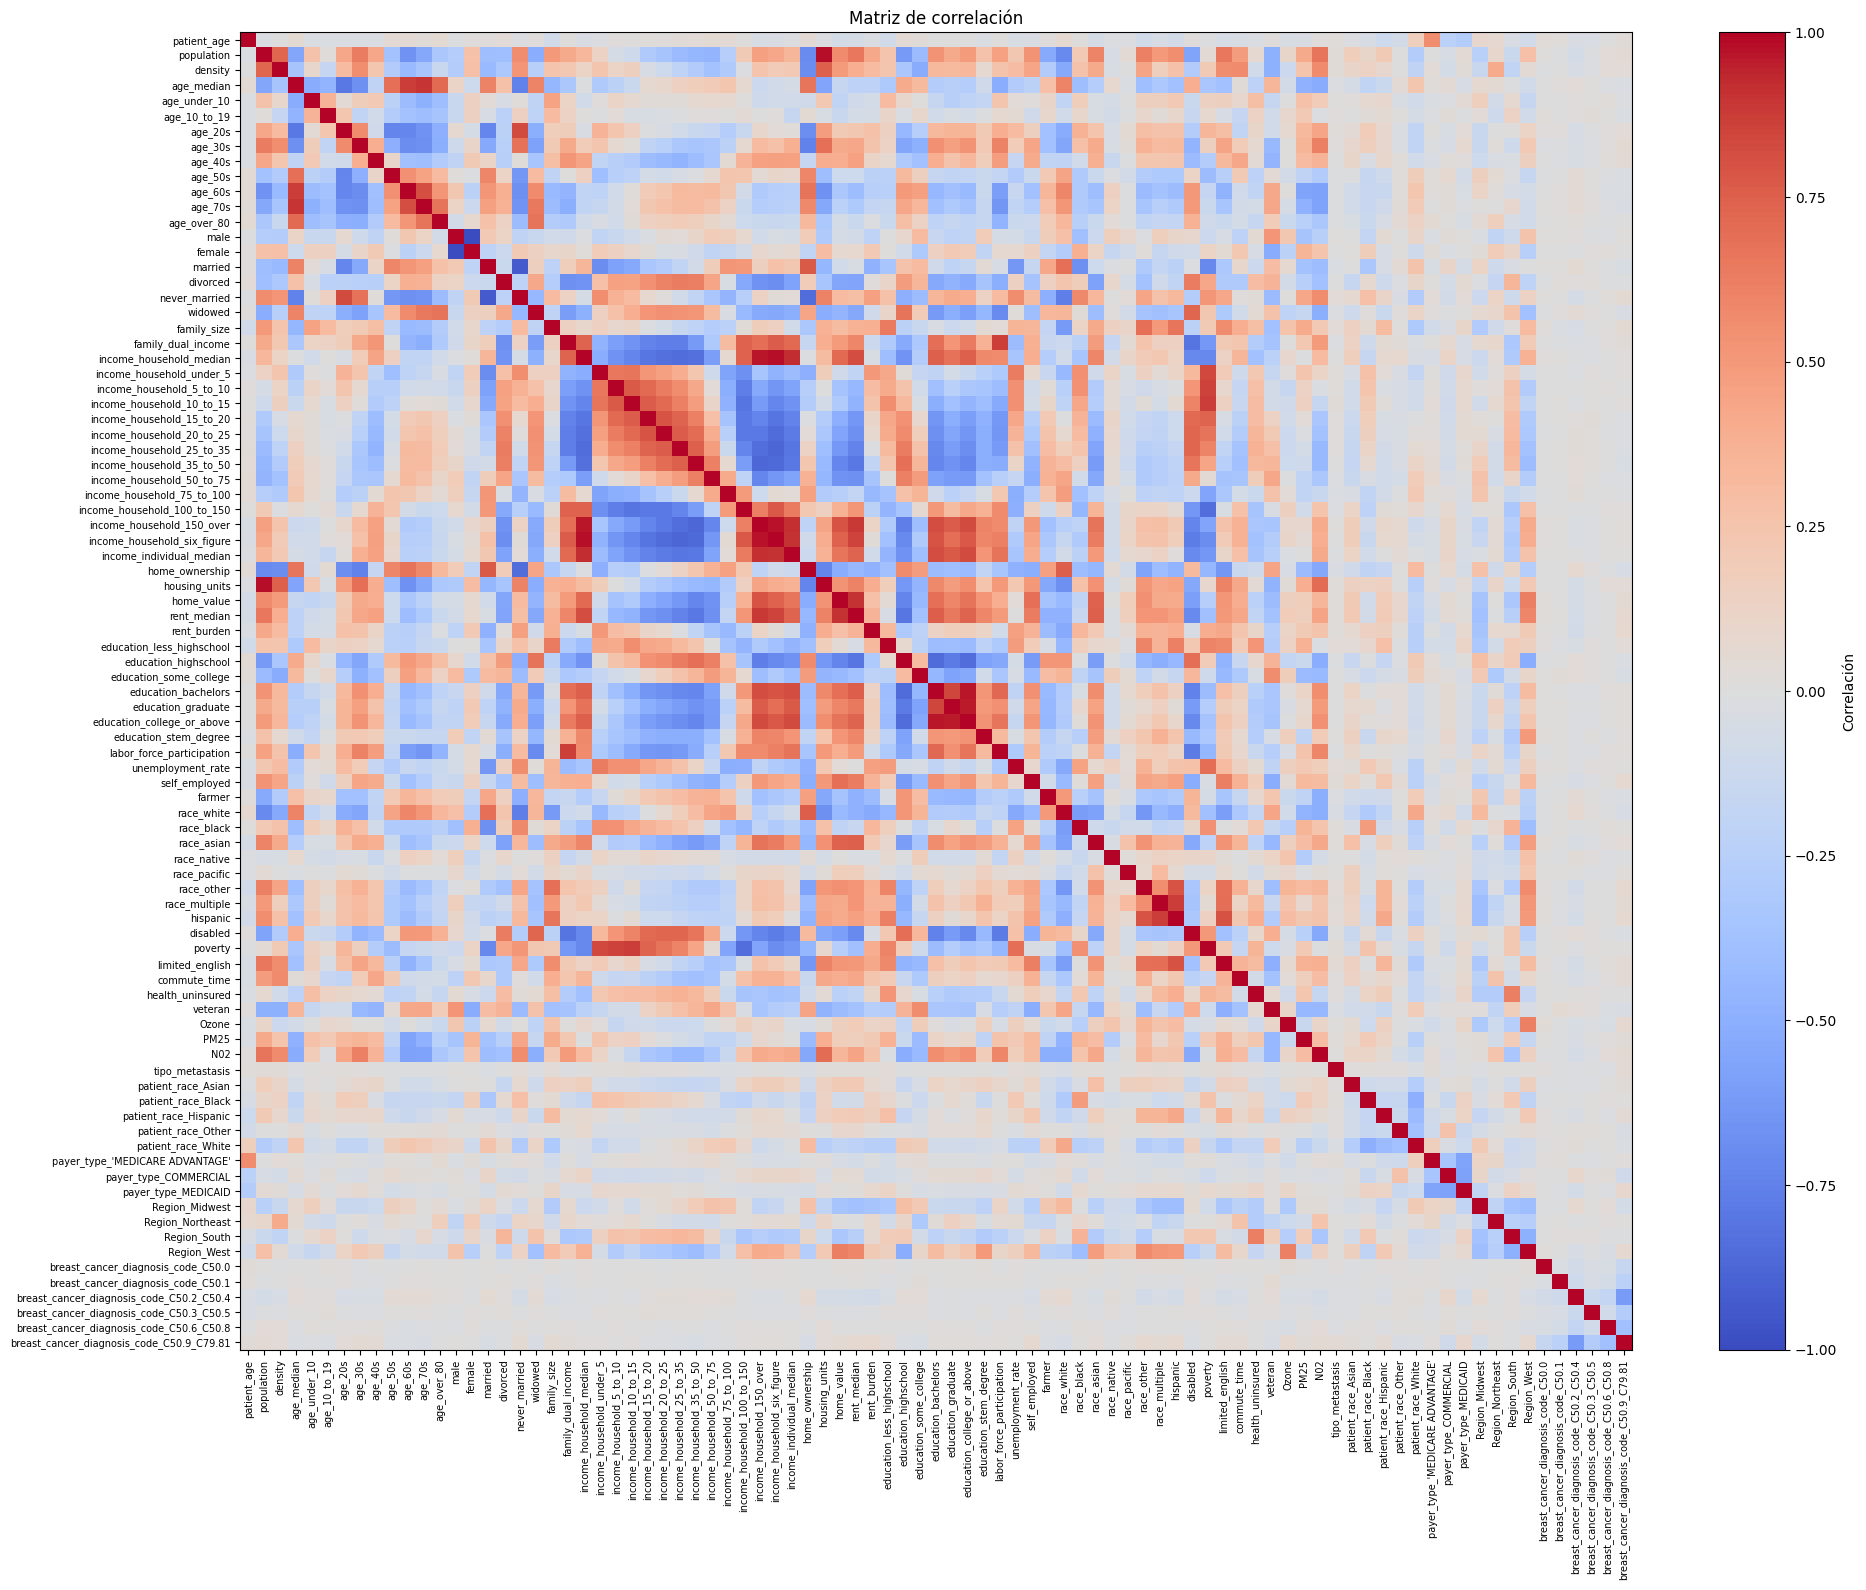


CORRELACIONES ALTAS ±0.8
                 Variable 1                  Variable 2  Correlación
    income_household_median income_household_six_figure     0.979577
                 population               housing_units     0.979344
  income_household_150_over income_household_six_figure     0.972936
    income_household_median   income_household_150_over     0.963967
        education_bachelors  education_college_or_above     0.961610
         education_graduate  education_college_or_above     0.956311
                    married               never_married    -0.926943
    income_household_median    income_individual_median     0.919293
  income_household_150_over    income_individual_median     0.906904
income_household_six_figure    income_individual_median     0.905203
                 home_value                 rent_median     0.902218
                 age_median                     age_70s     0.896294
  income_household_150_over                 rent_median     0.883609
  income

In [ ]:
# Librerías
import seaborn as sns
correlacion=df.corr(numeric_only=True)

# Matriz de correlación
plt.figure(figsize=(20, 16))

plt.imshow(
    correlacion,
    cmap="coolwarm",
    aspect="auto",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    fontsize=7
)

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

# Se recorre la matriz para obtener las correlaciones mayor a 0.8
pares = []

for i in range(len(correlacion.columns)):

    for j in range(i + 1, len(correlacion.columns)):

        valor = correlacion.iloc[i, j]

        # AQUÍ SE DEFINE EL CRITERIO ±0.8
        if 0.8<= abs(valor)<=0.99:
            pares.append([
                correlacion.columns[i],
                correlacion.columns[j],
                valor
            ])

correlaciones_altas = pd.DataFrame(
    pares,
    columns=[
        "Variable 1",
        "Variable 2",
        "Correlación"
    ]
)

if not correlaciones_altas.empty:

    correlaciones_altas["Valor absoluto"] = (
        correlaciones_altas["Correlación"].abs()
    )

    correlaciones_altas = correlaciones_altas.sort_values(
        "Valor absoluto",
        ascending=False
    )

    correlaciones_altas = correlaciones_altas.drop(
        columns=["Valor absoluto"]
    )


# Se muestran las correlaciones mayor a 0.8

print("\n====================================")
print("CORRELACIONES ALTAS ±0.8")
print("====================================")

if correlaciones_altas.empty:

    print("No se encontraron correlaciones de ±0.8.")

else:

    print(correlaciones_altas.to_string(index=False))

Analisis de correlación para irrelevancia con la variable objetivo
> Criterio: Se eliminan variables con correlación muy baja con la variable
objetivo (inferior a 0.02).
> Variables con alta multicolinealidad y cual variable tiene menos correlacion con la variable objetivo

In [ ]:
import numpy as np
import pandas as pd

target = 'tipo_metastasis'

# 1. |r| de Pearson de cada variable con el target
corr_target = (
    df.corrwith(df[target], method='pearson', numeric_only=True)
        .drop(target, errors='ignore')
        .abs()
)

# 2. Añadir la correlación con el target a cada par (excluyendo el target de los pares)
tabla = correlaciones_altas[
    ~correlaciones_altas[['Variable 1', 'Variable 2']].isin([target]).any(axis=1)
].copy()

tabla['|r| V1 vs target'] = tabla['Variable 1'].map(corr_target)
tabla['|r| V2 vs target'] = tabla['Variable 2'].map(corr_target)

tabla['Eliminar (por par)'] = np.where(
    tabla['|r| V1 vs target'] < tabla['|r| V2 vs target'],
    tabla['Variable 1'],
    tabla['Variable 2']
)

print(tabla.to_string(index=False))

# 3. Selección final (greedy): evita eliminar de más en cadenas de variables
#    'tabla' ya viene ordenada por |correlación| descendente
eliminar = set()
for _, fila in tabla.iterrows():
    v1, v2 = fila['Variable 1'], fila['Variable 2']
    if v1 in eliminar or v2 in eliminar:
        continue  # el par ya quedó resuelto
    eliminar.add(v1 if corr_target[v1] < corr_target[v2] else v2)

print(f"\nVariables a eliminar ({len(eliminar)}):")
print(sorted(eliminar))

# 4. Dataset reducido
# exploratorio
df_reducido = df.drop(columns=list(eliminar))

                 Variable 1                  Variable 2  Correlación  |r| V1 vs target  |r| V2 vs target          Eliminar (por par)
    income_household_median income_household_six_figure     0.979577          0.006108          0.005192 income_household_six_figure
                 population               housing_units     0.979344          0.023658          0.019137               housing_units
  income_household_150_over income_household_six_figure     0.972936          0.000884          0.005192   income_household_150_over
    income_household_median   income_household_150_over     0.963967          0.006108          0.000884   income_household_150_over
        education_bachelors  education_college_or_above     0.961610          0.005069          0.005562         education_bachelors
         education_graduate  education_college_or_above     0.956311          0.005618          0.005562  education_college_or_above
                    married               never_married    -0.926943 

{'age_60s',
 'age_70s',
 'disabled',
 'education_bachelors',
 'education_college_or_above',
 'housing_units',
 'income_household_100_to_150',
 'income_household_150_over',
 'income_household_median',
 'income_household_six_figure',
 'income_individual_median',
 'labor_force_participation',
 'married',
 'never_married',
 'poverty',
 'race_multiple',
 'rent_median'}

Variables con baja correlacion lineal con la variable objetivo

In [ ]:
lista_eliminar = sorted(eliminar)   # lista ordenada alfabéticamente, resultado reproducible
print(lista_eliminar)

['age_60s', 'age_70s', 'disabled', 'education_bachelors', 'education_college_or_above', 'housing_units', 'income_household_100_to_150', 'income_household_150_over', 'income_household_median', 'income_household_six_figure', 'income_individual_median', 'labor_force_participation', 'married', 'never_married', 'poverty', 'race_multiple', 'rent_median']


Guardando las variables las correlaciones para analizar en excel.

In [ ]:
#Correlaciones no lineales para análisis
#cor_variable_interes=abs(correlacion.loc['tipo_metastasis']).sort_values(ascending=False)
#cor_variable_interes.to_csv('cor_variable_interes.csv')

# Correlaciones no lineales

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Separar variables predictoras y variable objetivo
X = df.drop('tipo_metastasis', axis=1)
Y = df['tipo_metastasis']

# Calcular información mutua
bestfeatures = mutual_info_classif(X, Y, random_state=42)

# Crear tabla con nombre de variable y puntuación
resultado = pd.DataFrame({
    'Variable': X.columns,
    'Informacion_Mutua': bestfeatures
})

# Ordenar de mayor a menor
resultado = resultado.sort_values(
    by='Informacion_Mutua',
    ascending=False
).reset_index(drop=True)

# Mostrar la tabla
resultado

,Variable,Informacion_Mutua
0,breast_cancer_diagnosis_code_C50.9_C79.81,0.030164
1,education_stem_degree,0.023712
2,never_married,0.023634
3,age_20s,0.023542
4,age_70s,0.021751
...,...,...
81,payer_type_'MEDICARE ADVANTAGE',0.000000
82,Region_Midwest,0.000000
83,breast_cancer_diagnosis_code_C50.0,0.000000
84,Region_South,0.000000


Despúes de analizar las correlaciones lineales y no lineales la siguiente lista agrupa aquellas variables que obtuvieron baja correlacion lineal y no lineal. Aquellas variables que eran dummies, se elimina la variable de raiz.
> La selección final de variables se validó también con un análisis complementario
> en Excel (fuera de este notebook). La lista siguiente refleja esa decisión final.


In [ ]:
# Variables a eliminar
variable_eliminar = [
    "PM25",
    "race_black",
    "home_value",
    "race_asian",
    "income_household_50_to_75",
    "income_household_5_to_10",
    "income_household_under_5",
    "family_dual_income",
    "widowed",
    "age_20s",
    "age_50s",
    "commute_time",
    "health_uninsured",
    "age_30s",
    "age_over_80",
    "income_household_15_to_20",
    "income_household_20_to_25",
    "income_household_25_to_35",
    "age_10_to_19",
    "N02",
    "divorced",
    "race_native",
    "education_stem_degree",
    "race_pacific",
    "education_graduate",
    "age_under_10",
    "male",
    "female",
    "age_40s",
    "education_some_college",
    "income_household_35_to_50",
    "Region",
    "patient_race",
]

data_final = data.drop(columns=variable_eliminar, errors='raise')

print(f"Columnas antes: {data.shape[1]} → Después: {data_final.shape[1]}")
data_final.head()


Columnas antes: 73 → Después: 40


,payer_type,patient_age,breast_cancer_diagnosis_code,population,density,age_median,age_60s,age_70s,married,never_married,family_size,income_household_median,income_household_10_to_15,income_household_75_to_100,income_household_100_to_150,income_household_150_over,income_household_six_figure,income_individual_median,home_ownership,housing_units,rent_median,rent_burden,education_less_highschool,education_highschool,education_bachelors,education_college_or_above,labor_force_participation,unemployment_rate,self_employed,farmer,race_white,race_other,race_multiple,hispanic,disabled,poverty,limited_english,veteran,Ozone,tipo_metastasis
0,COMMERCIAL,62,C50.2_C50.4,39121.878790,2295.939394,38.200000,10.248485,5.951515,50.245455,35.290909,3.622727,102741.63640,2.648485,12.469697,19.760606,29.596970,49.357576,41287.27273,61.463636,11725.666670,2003.125000,34.753125,14.230303,19.987879,23.739394,35.984848,65.230303,5.103030,15.224242,0.027273,54.030303,11.645455,10.081818,37.948485,8.957576,10.109091,8.057576,4.103030,42.301121,1
1,COMMERCIAL,43,C50.1,21996.683330,626.236667,37.906667,11.426667,6.565000,55.753333,27.195000,3.260667,85984.74138,2.716667,13.560000,20.875000,18.680000,39.555000,40399.03333,72.745000,7786.583333,1235.907407,29.358491,10.811667,27.038333,19.678333,29.793333,66.428333,4.560000,13.722034,3.650847,75.820000,3.816667,6.898333,19.370000,11.253333,9.663333,3.356667,7.446667,40.108207,1
2,COMMERCIAL,45,C50.2_C50.4,32795.325580,1896.220930,42.871429,12.280952,8.216667,52.604762,31.142857,3.098095,120533.83330,2.180952,10.721429,18.850000,38.057143,56.907143,55336.28571,59.221429,12171.302330,2354.738095,32.030952,5.835714,12.145238,33.285714,55.745238,64.430952,5.264286,18.502381,0.052381,65.014286,5.428571,8.611905,16.716667,8.845238,8.688095,5.280952,4.809524,42.070075,1
3,'MEDICARE ADVANTAGE',66,C50.9_C79.81,5643.771429,219.362857,45.180000,15.685714,9.445714,51.322857,30.831429,2.908788,71005.10000,3.588235,14.500000,19.488235,11.400000,30.888235,35780.84375,83.873529,2368.942857,794.625000,26.647059,8.300000,36.882857,15.874286,25.740000,60.934286,3.882857,7.070968,1.645161,93.528571,1.000000,3.262857,2.465714,13.717143,8.888235,0.638235,7.745714,40.107248,2
4,COMMERCIAL,60,C50.3_C50.5,3404.100000,25.733333,42.790000,14.043333,8.526667,55.886667,24.526667,2.892667,60431.16667,3.576667,13.230000,17.080000,7.316667,24.396667,32379.13333,78.866667,1411.433333,711.259259,23.204167,9.813333,40.360000,12.003333,17.256667,61.740000,5.776667,12.253846,6.719231,96.406667,0.406667,1.913333,2.723333,15.260000,10.890000,0.503333,7.506667,37.646770,1


**Datos para clasificación**

In [ ]:
# Variables a utilizar
data_final.columns

Index(['payer_type', 'patient_age', 'breast_cancer_diagnosis_code',
       'population', 'density', 'age_median', 'age_60s', 'age_70s', 'married',
       'never_married', 'family_size', 'income_household_median',
       'income_household_10_to_15', 'income_household_75_to_100',
       'income_household_100_to_150', 'income_household_150_over',
       'income_household_six_figure', 'income_individual_median',
       'home_ownership', 'housing_units', 'rent_median', 'rent_burden',
       'education_less_highschool', 'education_highschool',
       'education_bachelors', 'education_college_or_above',
       'labor_force_participation', 'unemployment_rate', 'self_employed',
       'farmer', 'race_white', 'race_other', 'race_multiple', 'hispanic',
       'disabled', 'poverty', 'limited_english', 'veteran', 'Ozone',
       'tipo_metastasis'],
      dtype='object')